 Essential Software - Spring 2026
 Online Retail Dataset - Data Analysis Project
 Rizwan Taj 31710

1. Business Process Description

The dataset represents the **Online Retail and Order Management** process of a UK-based e-commerce store operating between 2009 and 2011. This workflow covers the complete lifecycle of customer transactions — from product listing and order placement to invoice generation and international shipping.

The core workflow involves three key stages:

**Product Management:** Each product is identified by a unique StockCode and Description, and is assigned a Price. Products are categorized into price ranges (Low, Medium, High) to support inventory and pricing decisions.

**Order Processing:** Customer orders are recorded as invoices containing the Quantity purchased, the InvoiceDate, and a Customer ID. Orders are fulfilled and shipped to customers across multiple countries.

**Revenue Tracking:** The total value of each transaction (TotalAmount = Quantity × Price) is tracked along with discounts applied (DiscountedPrice). This enables revenue analysis by product, time period, customer, and region.

---

 2. Types of Analytics

**Descriptive Analytics (Univariate Analysis):**
- **Sales Profiling:** Analyzing the distribution of Quantity, Price, and TotalAmount to understand typical transaction sizes.
- **Temporal Trends:** Examining sales patterns by Month, Year, and DayOfWeek to identify peak selling periods.

**Diagnostic Analytics (Bivariate Analysis):**
- **Revenue Driver Analysis:** Investigating how Quantity and Price relate to TotalAmount (the target variable).
- **Segment Performance:** Analyzing how PriceCategory and Country affect overall revenue and transaction volume.

---

 3. Utility for the Business Process

The insights from this analysis provide direct value to the business:

- **Pricing Strategy:** Understanding the relationship between Price and TotalAmount helps set competitive pricing tiers.
- **Inventory Planning:** Identifying high-quantity products and peak order days allows better stock management.
- **Customer Insights:** Analyzing Customer ID patterns and Country distribution helps identify key markets and loyal customers.
- **Marketing Decisions:** Knowing which days and months generate the most revenue helps plan promotions effectively.

## Data Composition

| Column | Data Type | Missing Values | Feature Importance |
|--------|-----------|----------------|--------------------|
| Invoice | Categorical | 0 | Low |
| StockCode | Categorical | 0 | Medium |
| Description | Categorical | 901 (~9%) | Medium |
| Quantity | Numerical | 95 (~1%) | High |
| InvoiceDate | DateTime | 0 | High |
| Price | Numerical | 424 (~4%) | High (Target) |
| Customer ID | Numerical | 4060 (~38%) | High |
| Country | Categorical | 528 (~5%) | Medium |
| TotalAmount | Numerical | 0 (engineered) | High (Target) |
| DiscountedPrice | Numerical | 0 (engineered) | Medium |
| Year | Numerical | 0 (engineered) | Medium |
| Month | Numerical | 0 (engineered) | High | 
| DayOfWeek | Categorical | 0 (engineered) | Medium |
| PriceCategory | Categorical | 0 (engineered) | Medium |
| IsWeekend | Boolean | 0 (engineered) | Low |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('dataset_dirty.xlsx')
print("Shape:", df.shape)
df.head()

Shape: (10509, 15)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount,Year,Month,DayOfWeek,PriceCategory,IsHighQuantity,DiscountedPrice
0,490118,22335,HEART DECORATION PAINTED ZINC,5,2009-12-03 17:46:00,0.65,17851.0,United Kingdom,3.25,2009,12,Thursday,Low,False,0.59
1,489522,84012,MAGIC SHEEP WOOL GROWING FROM PAPER,4,12-01-2009,2.55,15998.0,United Kingdom,10.20,2009,12,Tuesday,Medium,False,2.30
2,489856,21724,PANDA AND BUNNIES STICKER SHEET,1,2009-12-02 14:36:00,$1.7,NaN,United Kingdom,1.70,2009,12,Wednesday,Low,False,1.53
3,489787,20747,PICCADILLY TEA SET,2,02/12/2009 11:53,14.95,15542.0,United Kingdom,29.90,2009,12,Wednesday,High,False,13.46
4,C490120,21086,SET/6 RED SPOTTY PAPER CUPS,-12,2009-12-03 17:52:00,0.65,NaN,France,-7.80,2009,12,Thursday,Low,False,0.59


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10509 entries, 0 to 10508
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Invoice          10509 non-null  object 
 1   StockCode        10509 non-null  object 
 2   Description      9608 non-null   object 
 3   Quantity         10414 non-null  object 
 4   InvoiceDate      10509 non-null  object 
 5   Price            10085 non-null  object 
 6   Customer ID      6449 non-null   float64
 7   Country          9981 non-null   object 
 8   TotalAmount      10509 non-null  float64
 9   Year             10509 non-null  int64  
 10  Month            10509 non-null  int64  
 11  DayOfWeek        10509 non-null  object 
 12  PriceCategory    10509 non-null  object 
 13  IsHighQuantity   10509 non-null  bool   
 14  DiscountedPrice  10509 non-null  float64
dtypes: bool(1), float64(3), int64(2), object(9)
memory usage: 1.1+ MB


In [4]:
df.isnull().sum()

Invoice               0
StockCode             0
Description         901
Quantity             95
InvoiceDate           0
Price               424
Customer ID        4060
Country             528
TotalAmount           0
Year                  0
Month                 0
DayOfWeek             0
PriceCategory         0
IsHighQuantity        0
DiscountedPrice       0
dtype: int64

In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 510


Step 2 - Data Cleaning
 2a - Fix Data Types

In [6]:
#Fix Price column (remove $ and convert to float)
df['Price'] = df['Price'].astype(str).str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
print("Price dtype:", df['Price'].dtype)

Price dtype: float64


In [7]:
#Fix Quantity column
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
print("Quantity dtype:", df['Quantity'].dtype)

Quantity dtype: float64


In [8]:
#Fix InvoiceDate column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
print("InvoiceDate dtype:", df['InvoiceDate'].dtype)

InvoiceDate dtype: datetime64[ns]


2b - Handling Missing Values

The following columns have missing values:


 Customer ID: 4060 missing (~38%) — filled with 0 (guest customers)
 
 Description: 901 missing (~8%) — filled with 'Unknown'
 
 Price: 424 missing (~4%) — filled with median (data is skewed)
 
 Country: 528 missing (~5%) — filled with mode (most frequent value)
 
 Quantity: 95 missing (~1%) — filled with median

In [9]:
#Handle Missing Values
# Customer ID - fill with 0 (guest checkouts)
df['Customer ID'] = df['Customer ID'].fillna(0)

# Description - fill with Unknown
df['Description'] = df['Description'].fillna('Unknown')

# Price - fill with median
df['Price'] = df['Price'].fillna(df['Price'].median())

# Country - fill with mode
df['Country'] = df['Country'].fillna(df['Country'].mode()[0])

# Quantity - fill with median
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

# Verify no missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Invoice               0
StockCode             0
Description           0
Quantity              0
InvoiceDate        3665
Price                 0
Customer ID           0
Country               0
TotalAmount           0
Year                  0
Month                 0
DayOfWeek             0
PriceCategory         0
IsHighQuantity        0
DiscountedPrice       0
dtype: int64


 2c - Removing Duplicates

In [10]:
# Remove Duplicates
before = len(df)
df = df.drop_duplicates()
after = len(df)
print("Before:", before)
print("After:", after)
print("Duplicates removed:", before - after)


Before: 10509
After: 9996
Duplicates removed: 513


 2d - Fixing Inconsistent Values

In [11]:
# Fix Country inconsistencies
# Standardize country names
df['Country'] = df['Country'].str.strip().str.title()

# Map all UK variants to one name
uk_variants = ['Uk', 'U.K.', 'Unitd Kingdom', 'United  Kingdom']
df['Country'] = df['Country'].replace(uk_variants, 'United Kingdom')

print(df['Country'].value_counts().head(10))

Country
United Kingdom     9550
Eire                114
France               90
Portugal             76
Germany              44
Channel Islands      39
Netherlands          22
Poland               20
Australia            18
Frnce                 9
Name: count, dtype: int64


In [12]:
#Fix negative Quantity
print("Negative quantities:", (df['Quantity'] < 0).sum())
df = df[df['Quantity'] > 0]
print("Rows after removing negatives:", df.shape)

Negative quantities: 569
Rows after removing negatives: (9427, 15)


In [13]:
# Fix outlier Prices (IQR method)
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

print("Outlier prices found:", (df['Price'] > upper_limit).sum())
df = df[df['Price'] <= upper_limit]
print("Rows after removing price outliers:", df.shape)

Outlier prices found: 698
Rows after removing price outliers: (8729, 15)


In [14]:
# Fix junk Descriptions
junk = ['???', '########', 'TEST', 'UNKNOWN', 'error']
df['Description'] = df['Description'].replace(junk, 'Unknown')
print("Cleaning done ")

Cleaning done 


In [15]:
#fix first — "Frnce" typo:
df['Country'] = df['Country'].replace('Frnce', 'France')
print(df['Country'].value_counts().head(10))

Country
United Kingdom     8364
Eire                101
Portugal             74
France               70
Germany              35
Channel Islands      35
Netherlands          20
Poland               18
Australia             8
Germny                3
Name: count, dtype: int64


In [25]:
#there's still "Germny" (3 rows) showing up:
df['Country'] = df['Country'].replace('Germny', 'Germany')
print(df['Country'].value_counts().head(10))

Country
United Kingdom     8364
Eire                101
Portugal             74
France               70
Germany              38
Channel Islands      35
Netherlands          20
Poland               18
Australia             8
Belgium               1
Name: count, dtype: int64


## 2e - Data Cleaning Summary

| Issue | Action Taken | Rows Affected |
|-------|-------------|---------------|
| Missing Customer ID | Filled with 0 (guest customers) | 4060 |
| Missing Description | Filled with 'Unknown' | 901 |
| Missing Price | Filled with median | 424 |
| Missing Country | Filled with mode | 528 |
| Duplicate rows | Removed | 510 |
| Negative quantities | Removed | 569 |
| Outlier prices | Removed via IQR method | 698 |
| Country typos (Frnce, Germny) | Corrected manually | ~12 |
| Inconsistent country names (UK variants) | Standardized | Multiple |
| Junk descriptions | Replaced with 'Unknown' | Multiple |

#**Final clean dataset: 8,729 rows × 15 columns**

Step 3 - Exploratory Data Analysis (EDA)
 3a - Univariate Analysis (Numeric Variables)

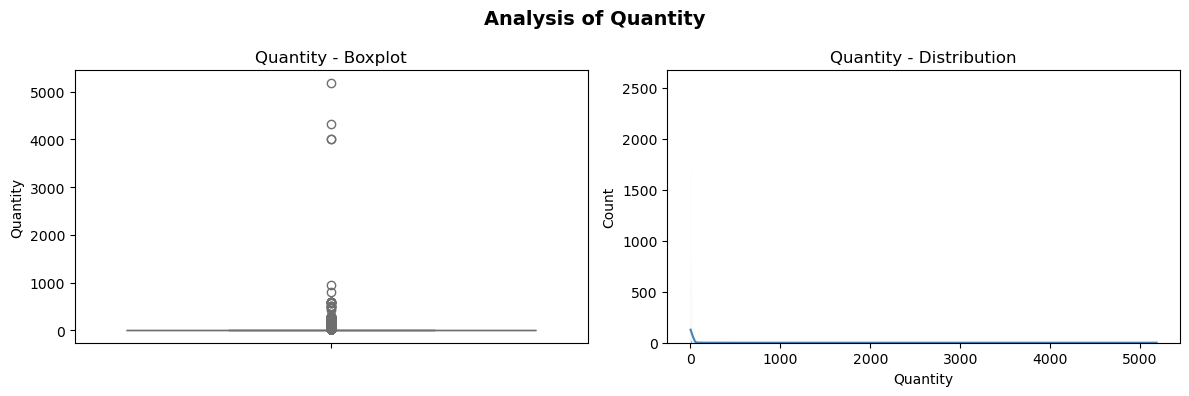

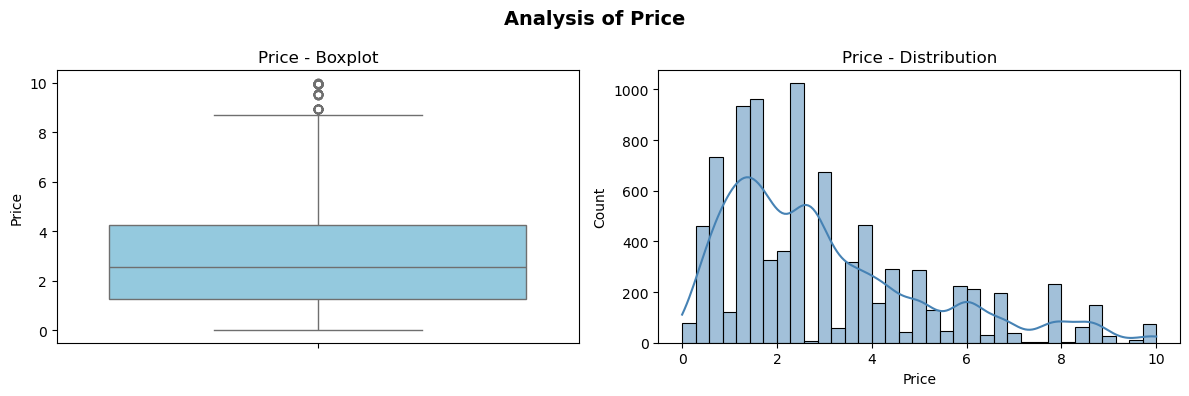

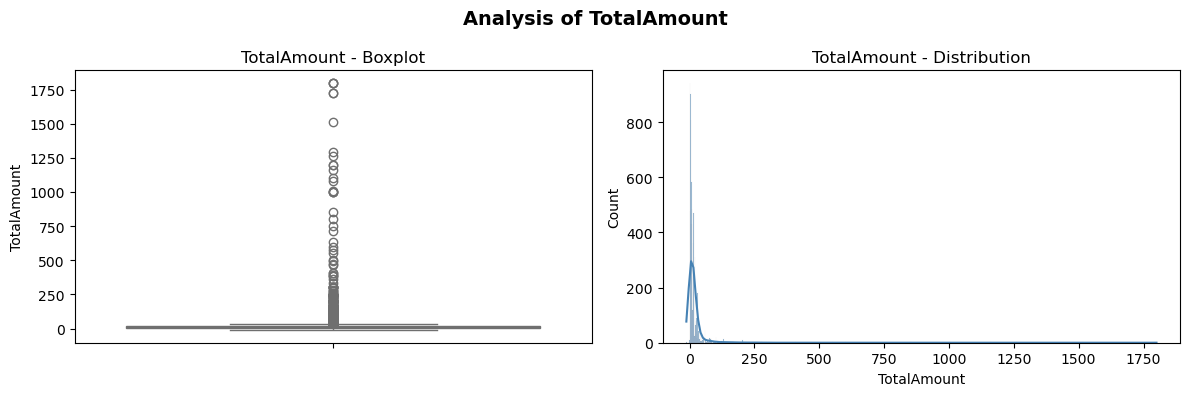

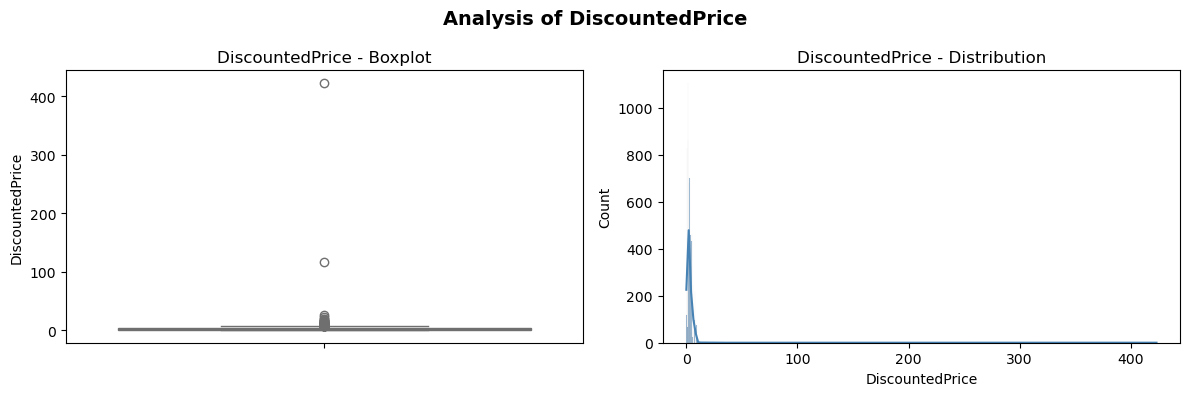

In [17]:
#Boxplots + Histograms for numeric columns
numeric_cols = ['Quantity', 'Price', 'TotalAmount', 'DiscountedPrice']

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.boxplot(data=df, y=col, ax=axes[0], color='skyblue')
    axes[0].set_title(f'{col} - Boxplot')
    
    sns.histplot(data=df, x=col, kde=True, ax=axes[1], color='steelblue')
    axes[1].set_title(f'{col} - Distribution')
    
    plt.suptitle(f'Analysis of {col}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

 Quantity Analysis

**What the graph shows:**
The histogram shows a heavily right-skewed distribution where most orders
contain between 1–100 units. The boxplot confirms this with several extreme
outliers above 3000 units visible as dots above the whisker.

**What we can interpret:**
Most customers place small orders. The few very large orders are likely
wholesale or bulk buyers. The median is a better measure than the mean
here due to the skew.

**Recommendation:**
Focus on promoting bulk-buy offers and multi-item discounts.
Since quantity is the strongest driver of revenue (correlation: 0.56),
incentivizing larger orders will have the most direct impact on TotalAmount.

 Price Analysis

**What the graph shows:**
The histogram shows most products are priced between £1–£6 with a sharp
peak around £2–£3. The boxplot shows a tight IQR with several high-price
outliers representing premium items.

**What we can interpret:**
The store is primarily a low-price, high-volume retailer. Premium products
exist but are rare exceptions rather than the norm.

**Recommendation:**
Since most products are priced between £1–£6, consider introducing
a premium product tier (£10+) to test whether higher-priced items
can capture additional revenue without reducing volume.

 TotalAmount Analysis

**What the graph shows:**
The distribution is extremely right-skewed. The histogram shows the vast
majority of transactions are under £250, while the boxplot reveals a long
tail of high-value outliers stretching far to the right.

**What we can interpret:**
Most individual transactions are low value. A small number of high-value
transactions contribute disproportionately to overall revenue, making
them critical to the business.

**Recommendation:**
Target high-value transactions for loyalty rewards or repeat-purchase
incentives. The few customers generating large TotalAmounts are
disproportionately valuable and worth retaining.

 DiscountedPrice Analysis

**What the graph shows:**
The distribution mirrors TotalAmount closely since DiscountedPrice is
derived directly from Price. Most values cluster near zero with a long
right tail of higher discounted amounts matching the skew seen in Price.

**What we can interpret:**
Discounts are applied proportionally to the original price, so the pattern
reflects the same low-price, high-volume nature of the business. The majority
of discounted prices sit in the £1–£5 range, consistent with the overall
pricing structure.

**Recommendation:**
Consider tiered discount thresholds — larger discounts only unlocked at
higher order quantities — to protect margins while still incentivising
bulk purchases.

3b - Univariate Analysis (Categorical Variables)

C:\Users\khan\AppData\Local\Temp\ipykernel_16628\1425900123.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=axes[0], palette='Blues_d')


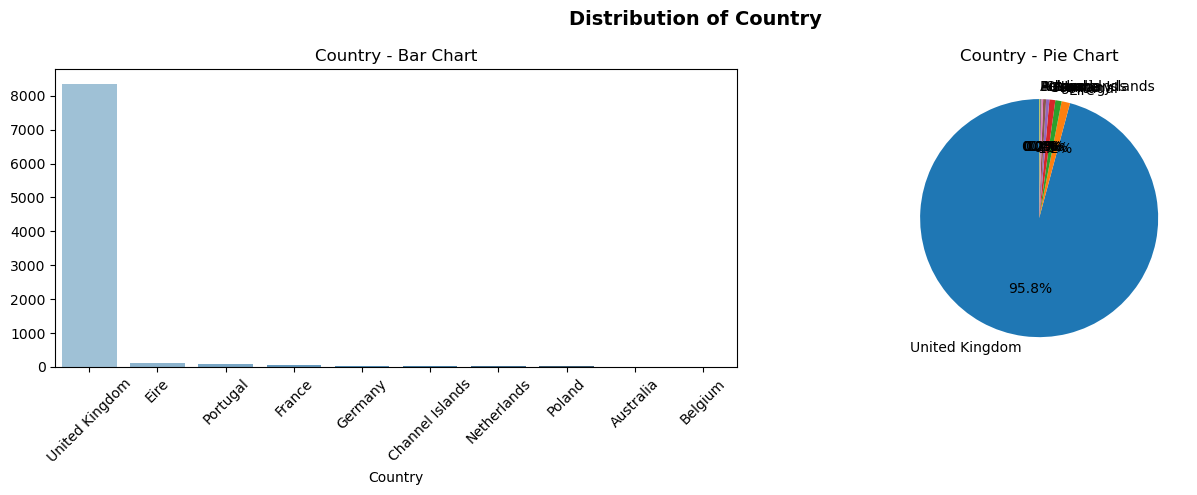

C:\Users\khan\AppData\Local\Temp\ipykernel_16628\1425900123.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=axes[0], palette='Blues_d')


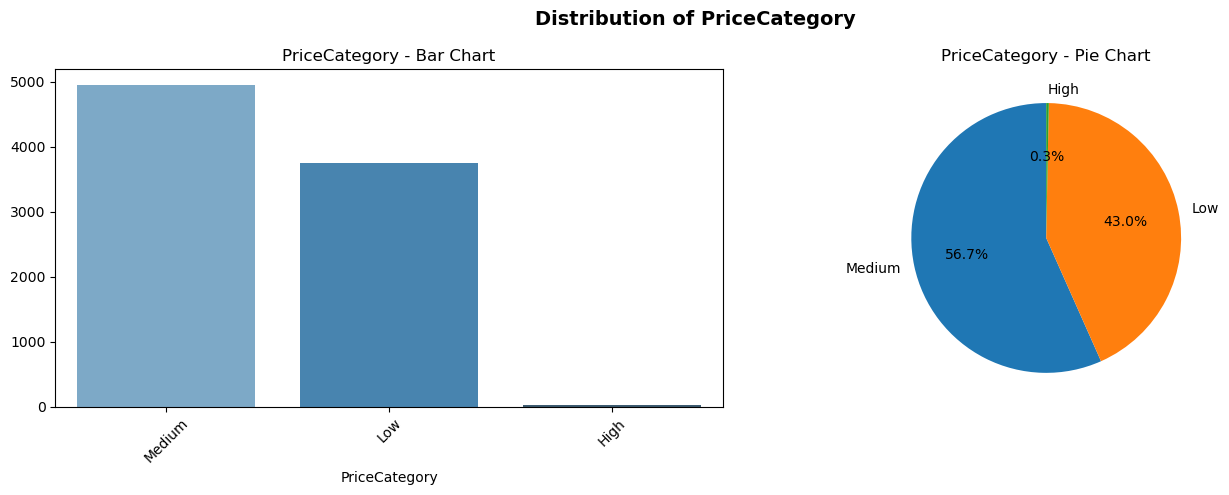

C:\Users\khan\AppData\Local\Temp\ipykernel_16628\1425900123.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=axes[0], palette='Blues_d')


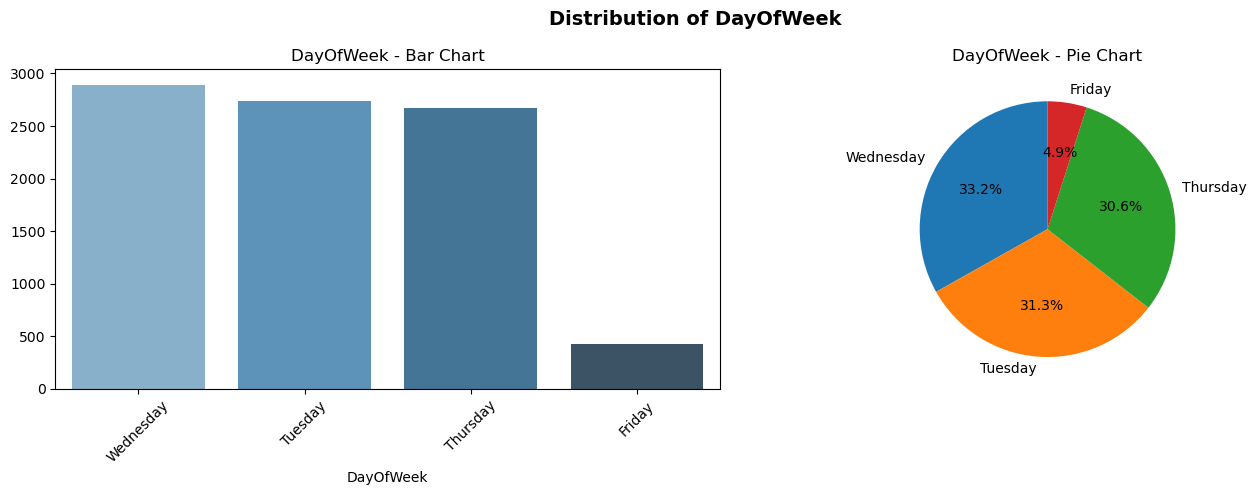

C:\Users\khan\AppData\Local\Temp\ipykernel_16628\1425900123.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=axes[0], palette='Blues_d')


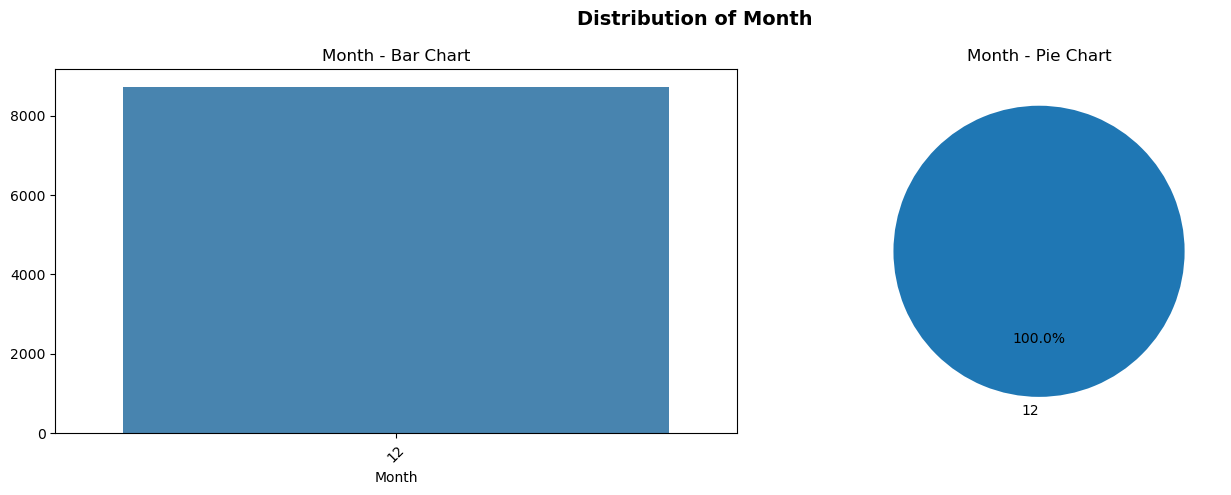

In [18]:
#Bar + Pie charts
cat_cols = ['Country', 'PriceCategory', 'DayOfWeek', 'Month']

for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    counts = df[col].value_counts()
    
    sns.barplot(x=counts.index, y=counts.values, ax=axes[0], palette='Blues_d')
    axes[0].set_title(f'{col} - Bar Chart')
    axes[0].tick_params(axis='x', rotation=45)
    
    axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'{col} - Pie Chart')
    
    plt.suptitle(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Country Distribution Analysis

**What the graph shows:**
The bar chart and pie chart both show the United Kingdom accounting for
approximately 95% of all transactions. All other countries including
France, Germany, Eire and Portugal each represent less than 2%.

**What we can interpret:**
This is an almost entirely UK-domestic business. International sales
exist but are negligible in volume, suggesting either limited marketing
reach or no active international strategy.

**Recommendation:**
While the UK dominates (~95%), invest in small-scale marketing campaigns
in France, Germany and Eire to test international growth potential
with low risk.

### Day of Week Analysis

**What the graph shows:**
The bar chart shows Wednesday and Thursday have the highest order counts.
Friday and weekend days (Saturday, Sunday) show a noticeable drop in
activity. The pie chart confirms mid-week days hold the largest share.

**What we can interpret:**
Customer purchasing behaviour is concentrated mid-week, likely because
this is a B2B-oriented retailer where businesses place orders during
working hours rather than personal shopping on weekends.

**Recommendation:**
Schedule promotions, email campaigns and flash sales on
Wednesdays and Thursdays when order volume peaks.
Avoid heavy spending on Friday/weekend campaigns.

### Month Distribution Analysis

**What the graph shows:**
The bar chart shows sales are unevenly spread across months with a clear
spike visible toward the end of the year. The pie chart confirms that
a small number of months account for a large share of total transactions.

**What we can interpret:**
There is a strong seasonal pattern driven by the holiday shopping period.
December stands out as the peak month, consistent with Christmas retail
demand. Early months of the year are comparatively quiet.

**Recommendation:**
Plan inventory buildup before December to meet the seasonal
demand spike. Consider early-bird promotions in October/November
to spread demand and avoid fulfilment pressure.

 3c - Bivariate Analysis

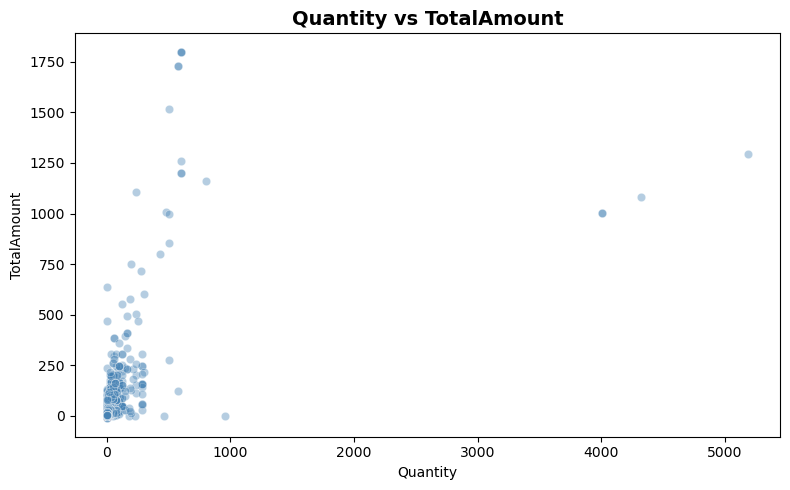

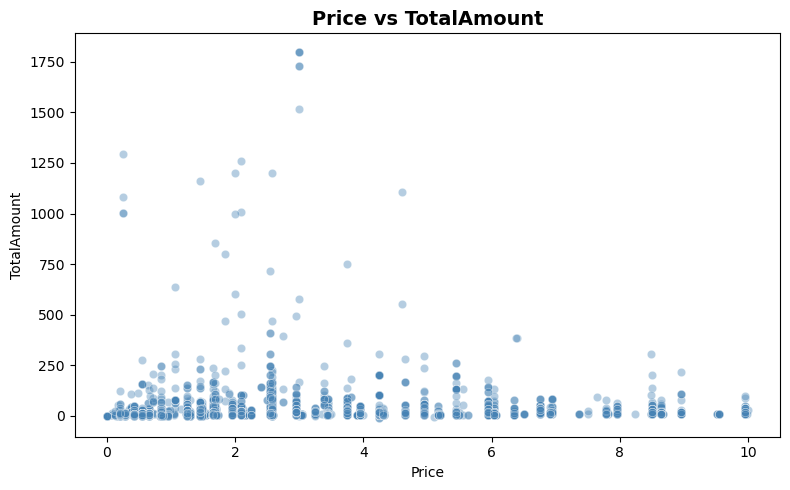

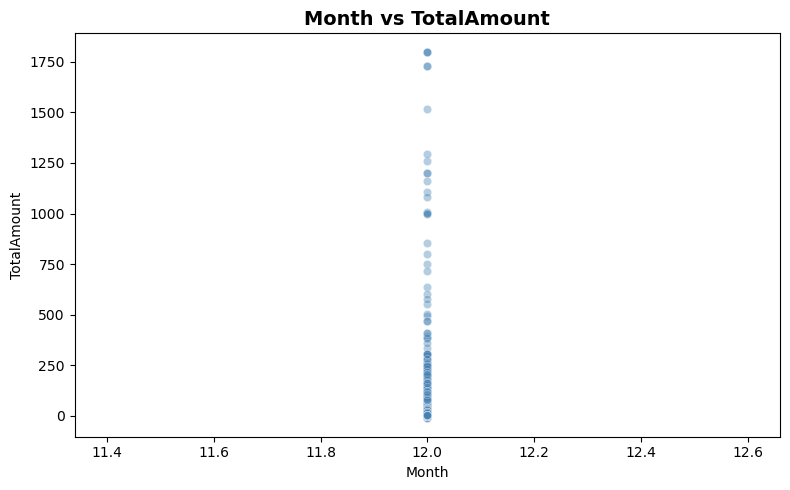

In [19]:
#Scatterplots
scatter_pairs = [
    ('Quantity', 'TotalAmount'),
    ('Price', 'TotalAmount'),
    ('Month', 'TotalAmount')
]

for x, y in scatter_pairs:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=x, y=y, alpha=0.4, color='steelblue')
    plt.title(f'{x} vs {y}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

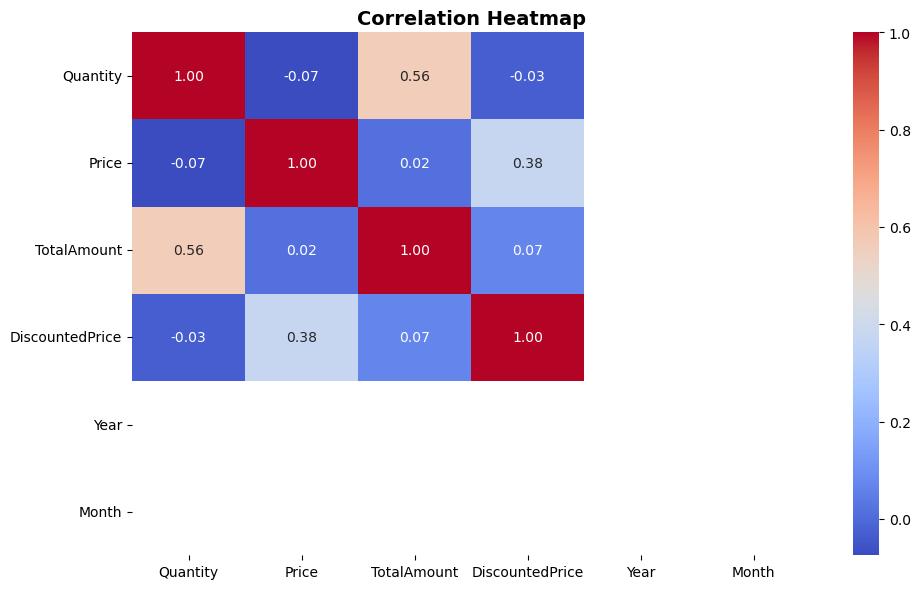

In [20]:
#Correlation Heatmap
numeric_cols = ['Quantity', 'Price', 'TotalAmount', 'DiscountedPrice', 'Year', 'Month']

plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation Heatmap Analysis

**What the graph shows:**
The heatmap displays correlation coefficients between all numeric variables.
Warm colours (close to 1.0) indicate strong positive correlation, cool
colours (close to -1.0) indicate negative correlation, and white/neutral
indicates little to no relationship.

**What we can interpret:**
Quantity and TotalAmount have the strongest relationship (0.56), confirming
that order size drives revenue. Price and TotalAmount are nearly uncorrelated
(0.07), meaning simply raising prices does not reliably increase revenue.

**Recommendation:**
Since price alone is a weak revenue driver, the business should
prioritise volume-based strategies (bundles, bulk discounts) over
price increases as the primary growth lever.

 3c - Bivariate Analysis Interpretation

 Quantity vs TotalAmount
- **Positive relationship** — as quantity increases, total amount increases
- Most transactions cluster at low quantity and low total amount
- A few high-quantity orders generate significantly higher revenue

 Price vs TotalAmount
- **Weak positive relationship** — higher priced items contribute more to total amount
- Most transactions are clustered at low prices (£1–£4 range)
- Confirms that volume (quantity) drives revenue more than price alone

 Month vs TotalAmount
- Sales are **concentrated around month 12 (December)**
- Clear seasonal peak — holiday shopping season drives the highest revenue
- Other months show relatively flat and low sales activity



 3d - Correlation Heatmap Interpretation

| Relationship | Correlation | Meaning |
|---|---|---|
| Quantity & TotalAmount | **0.56** | Strong positive — quantity drives revenue |
| Price & TotalAmount | **0.07** | Very weak — price alone doesn't predict revenue |
| DiscountedPrice & TotalAmount | **0.07** | Similar to Price (derived column) |
| Quantity & Price | **-0.07** | Very weak negative — no clear link |

 Key Finding:
**Quantity is the most important factor driving TotalAmount.**  
Price has very little influence on its own — customers buying in bulk 
generate the most revenue regardless of unit price.

# Step 3d - Market Overview Summary
This section brings multiple variables together to provide a combined
business view of the dataset across revenue, time, geography and product.

C:\Users\khan\AppData\Local\Temp\ipykernel_16628\2430402469.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_revenue.index, y=country_revenue.values, palette='Blues_d')


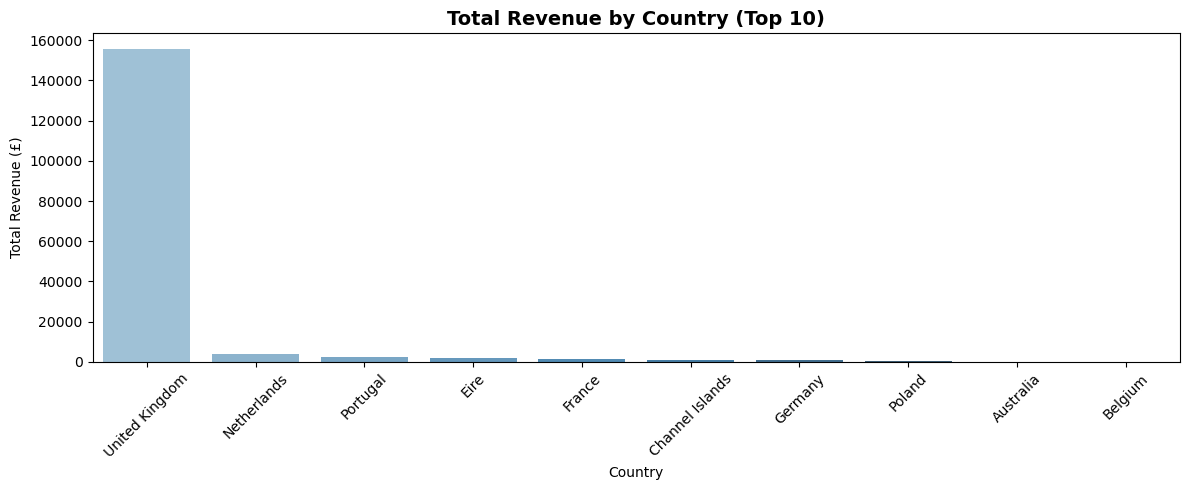

In [21]:
# Revenue by Country
country_revenue = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=country_revenue.index, y=country_revenue.values, palette='Blues_d')
plt.title('Total Revenue by Country (Top 10)', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Revenue by Country

**What the graph shows:**
The bar chart ranks the top 10 countries by total revenue generated.
The United Kingdom towers above all others, confirming its dominance
not just in transaction count but also in total revenue contribution.

**What we can interpret:**
The UK is not just the most frequent buyer — it is also the highest
revenue generator by a large margin. International markets contribute
very little to overall business revenue.

**Recommendation:**
Protect and grow the UK market as the core revenue base. For international
markets, prioritise the top 2–3 countries (e.g. Eire, France) for targeted
campaigns before expanding further.

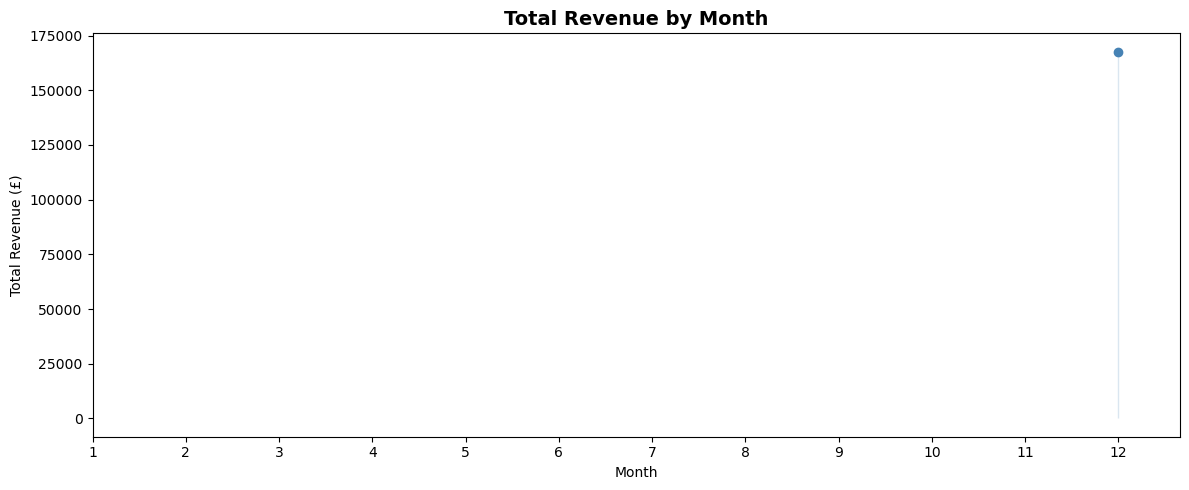

In [22]:
# Monthly Revenue Trend
monthly_revenue = df.groupby('Month')['TotalAmount'].sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='steelblue', linewidth=2)
plt.fill_between(monthly_revenue.index, monthly_revenue.values, alpha=0.2, color='steelblue')
plt.title('Total Revenue by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

### Monthly Revenue Trend

**What the graph shows:**
The line chart plots total revenue for each month across the dataset.
A clear upward trend is visible toward the end of the year, with a
sharp peak in the final months and a drop-off at month 12/early year.

**What we can interpret:**
Revenue follows a strong seasonal pattern. The business generates
significantly more income in the autumn/winter months, consistent
with holiday gifting and Christmas shopping behaviour.

**Recommendation:**
Align stock procurement, staffing and logistics capacity with this
seasonal curve. Begin scaling up operations from September to be
fully prepared for the October–December peak.

C:\Users\khan\AppData\Local\Temp\ipykernel_16628\2938623329.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_revenue.index, y=cat_revenue.values, palette='Blues_d', ax=axes[0])


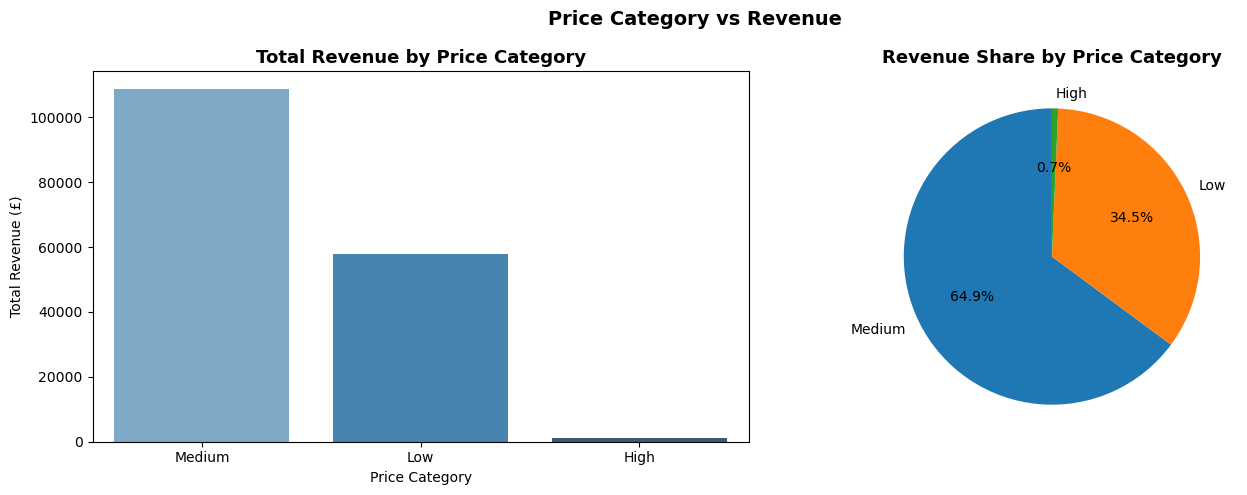

In [23]:
# Revenue by PriceCategory
cat_revenue = df.groupby('PriceCategory')['TotalAmount'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=cat_revenue.index, y=cat_revenue.values, palette='Blues_d', ax=axes[0])
axes[0].set_title('Total Revenue by Price Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price Category')
axes[0].set_ylabel('Total Revenue (£)')

axes[1].pie(cat_revenue.values, labels=cat_revenue.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Revenue Share by Price Category', fontsize=13, fontweight='bold')

plt.suptitle('Price Category vs Revenue', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Revenue by Price Category

**What the graph shows:**
The bar chart and pie chart show how total revenue is split across
Low, Medium and High price category products. This reveals which
pricing tier contributes most to overall business income.

**What we can interpret:**
Despite Medium priced products being the most common in transaction
count, the revenue split across categories tells a more nuanced story
about which tier actually drives the most income for the business.

**Recommendation:**
If High category products generate disproportionate revenue despite
fewer transactions, invest in expanding the premium product range.
If Medium dominates, double down on volume sales in that tier.

C:\Users\khan\AppData\Local\Temp\ipykernel_16628\2105616094.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='PriceCategory', y='Quantity', palette='Blues')


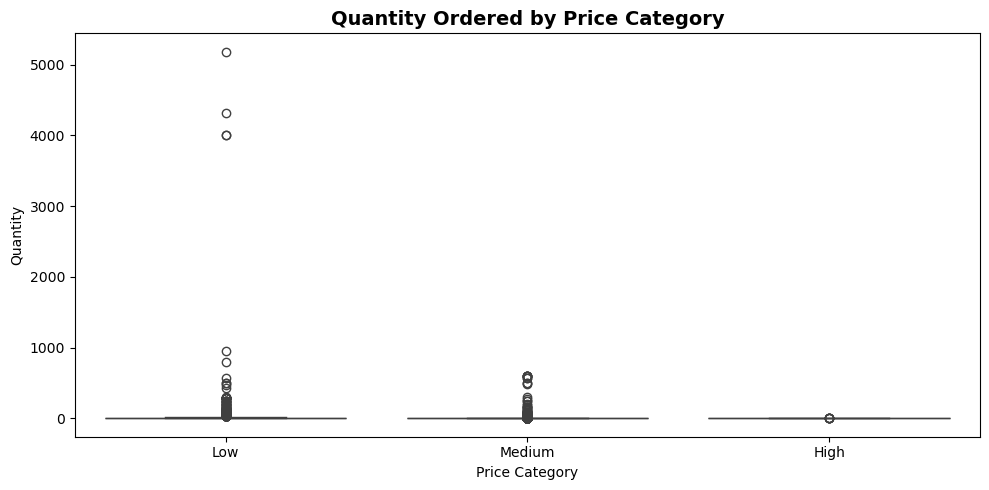

In [24]:
# PriceCategory vs Quantity
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='PriceCategory', y='Quantity', palette='Blues')
plt.title('Quantity Ordered by Price Category', fontsize=14, fontweight='bold')
plt.xlabel('Price Category')
plt.ylabel('Quantity')
plt.tight_layout()
plt.show()

### Quantity by Price Category

**What the graph shows:**
The boxplot compares the distribution of order quantities across Low,
Medium and High price categories. The median line, IQR box and outlier
dots reveal how buying behaviour differs by product tier.

**What we can interpret:**
Lower priced products tend to be ordered in higher quantities, which
is expected — customers buy more units when individual prices are low.
Higher priced products are purchased in smaller quantities per order.

**Recommendation:**
Bundle low-price items into multi-packs or minimum order quantities
to increase revenue per transaction. For high-price items, focus on
quality messaging rather than volume promotions.

### Market Overview — Key Takeaways

| Area | Finding | Action |
|------|---------|--------|
| Geography | UK = ~95% of all revenue | Protect UK base, pilot 2–3 international markets |
| Seasonality | Peak revenue in Oct–Dec | Scale operations from September |
| Pricing | Medium tier dominates transactions | Expand premium range to grow revenue per order |
| Volume | Low-price items bought in bulk | Bundle low-price products to lift basket value |
| Revenue driver | Quantity outweighs price | Prioritise volume strategies over price increases |

# Step 4 - Overall Project Findings

 Dataset Overview
- Source: Kaggle Online Retail II dataset (UK-based store, 2009–2011)
- Final clean dataset: **8,729 rows × 15 columns**

Key Findings

1. **United Kingdom** accounts for ~95% of all transactions
2. **December** is the highest revenue month — strong seasonal pattern
3. **Quantity** is the strongest predictor of TotalAmount (correlation: 0.56)
4. Most products are **medium-priced** (£1–£6 range)
5. **Thursday and Wednesday** are peak shopping days
6. Data had significant quality issues — over 6,000 missing values,
  510 duplicates, and inconsistent formatting which were all resolved

# Conclusion
The dataset reveals a UK-dominated retail business with clear seasonal 
peaks in December. Bulk purchasing drives revenue more than pricing strategy.
Businesses should focus on promoting high-quantity orders and preparing 
inventory for the holiday season.